#Menggunakan EfficientNetV2B0 di Dataset Baru

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!rm -rf "/content/dataset"
!rsync -ah --info=progress2 "/content/drive/MyDrive/dataset/" "/content/dataset/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
        202.53M 100%    2.68MB/s    0:01:12 (xfr#7500, to-chk=0/7504)


In [ ]:
DATASET_PATH = "/content/dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42
EPOCHS = 100

In [ ]:
import os
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
dataset_dir = Path(DATASET_PATH)

class_counts = []

for class_folder in dataset_dir.iterdir():
    if class_folder.is_dir():
        total_images = len(list(class_folder.glob("*")))
        class_counts.append({
            "Kelas": class_folder.name,
            "Jumlah": total_images
        })

df_counts = pd.DataFrame(class_counts)
df_counts

,Kelas,Jumlah
0,Penuh,2500
1,Kosong,2500
2,Terisi,2500


In [ ]:
image_paths = []
labels = []

valid_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

for class_folder in dataset_dir.iterdir():
    if class_folder.is_dir():
        for img_path in class_folder.glob("*"):
            if img_path.suffix.lower() in valid_extensions:
                image_paths.append(str(img_path))
                labels.append(class_folder.name)

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

df.head()

,image_path,label
0,/content/dataset/Penuh/Penuh_aug_0299.jpg,Penuh
1,/content/dataset/Penuh/Penuh_aug_0479.jpg,Penuh
2,/content/dataset/Penuh/Penuh_original_0143.jpg,Penuh
3,/content/dataset/Penuh/Penuh_aug_1917.jpg,Penuh
4,/content/dataset/Penuh/Penuh_aug_1856.jpg,Penuh


In [ ]:
print("Total gambar:", len(df))
print("Jumlah kelas:", df["label"].nunique())
print("Nama kelas:", sorted(df["label"].unique()))

Total gambar: 7500
Jumlah kelas: 3
Nama kelas: ['Kosong', 'Penuh', 'Terisi']


In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Jumlah data train:", len(train_df))
print("Jumlah data validation:", len(val_df))
print("Jumlah data test:", len(test_df))

print("\nDistribusi train:")
print(train_df["label"].value_counts())

print("\nDistribusi validation:")
print(val_df["label"].value_counts())

print("\nDistribusi test:")
print(test_df["label"].value_counts())

Jumlah data train: 5250
Jumlah data validation: 1125
Jumlah data test: 1125

Distribusi train:
label
Penuh     1750
Kosong    1750
Terisi    1750
Name: count, dtype: int64

Distribusi validation:
label
Kosong    375
Terisi    375
Penuh     375
Name: count, dtype: int64

Distribusi test:
label
Kosong    375
Terisi    375
Penuh     375
Name: count, dtype: int64


In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_generator = test_val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = test_val_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)

print("Class indices:", train_generator.class_indices)
print("Jumlah kelas:", num_classes)

Found 5250 validated image filenames belonging to 3 classes.
Found 1125 validated image filenames belonging to 3 classes.
Found 1125 validated image filenames belonging to 3 classes.
Class indices: {'Kosong': 0, 'Penuh': 1, 'Terisi': 2}
Jumlah kelas: 3


In [ ]:
base_model = EfficientNetV2B0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_2     │ (None, 224, 224,  │          0 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization_2[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b

 Total params: 6,083,667 (23.21 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [ ]:
checkpoint = ModelCheckpoint(
    "best_efficientnetv2b0_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    mode="max",
    restore_best_weights=True,
    verbose=1
)

callbacks = [checkpoint, early_stop]

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9439 - loss: 0.1352
Epoch 1: val_accuracy improved from None to 0.95200, saving model to best_efficientnetv2b0_model.keras

Epoch 1: finished saving model to best_efficientnetv2b0_model.keras
329/329 ━━━━━━━━━━━━━━━━━━━━ 441s 1s/step - accuracy: 0.9396 - loss: 0.1425 - val_accuracy: 0.9520 - val_loss: 0.1096
Epoch 2/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9480 - loss: 0.1353
Epoch 2: val_accuracy did not improve from 0.95200
329/329 ━━━━━━━━━━━━━━━━━━━━ 431s 1s/step - accuracy: 0.9442 - loss: 0.1360 - val_accuracy: 0.9413 - val_loss: 0.1336
Epoch 3/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9465 - loss: 0.1260
Epoch 3: val_accuracy did not improve from 0.95200
329/329 ━━━━━━━━━━━━━━━━━━━━ 432s 1s/step - accuracy: 0.9461 - loss: 0.1271 - val_accuracy: 0.9520 - val_loss: 0.1119
Epoch 4/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9548 - loss: 0.1225
Epoch 4: val_accuracy did no

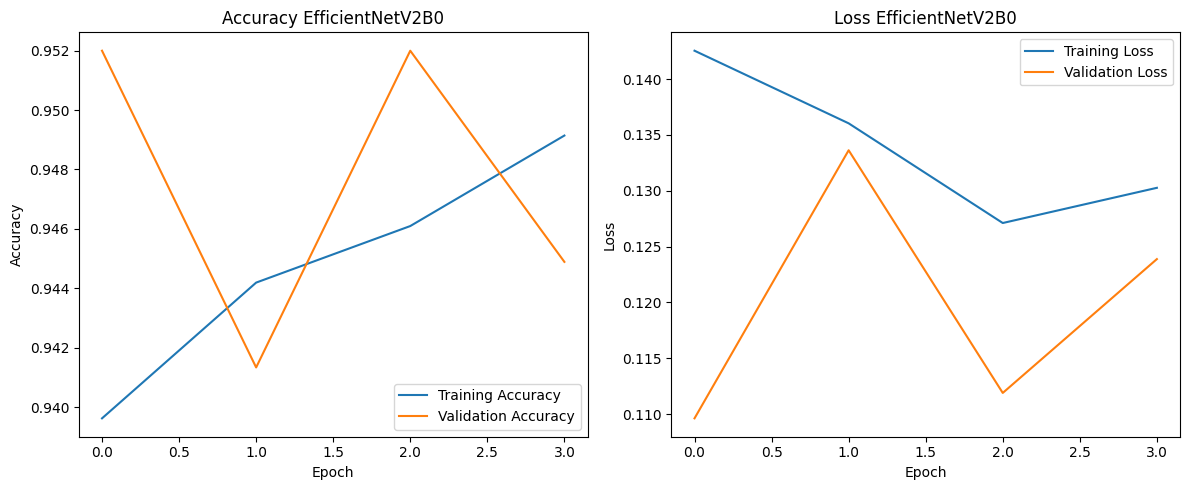

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy EfficientNetV2B0")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss EfficientNetV2B0")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
test_generator.reset()

y_pred_prob = model.predict(test_generator)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_generator.classes

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print("===== Evaluasi EfficientNetV2B0 =====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

71/71 ━━━━━━━━━━━━━━━━━━━━ 70s 950ms/step
===== Evaluasi EfficientNetV2B0 =====
Accuracy  : 0.9564
Precision : 0.9583
Recall    : 0.9564
F1-Score  : 0.9567

Classification Report:
              precision    recall  f1-score   support

      Kosong       1.00      0.95      0.97       375
       Penuh       0.97      0.94      0.96       375
      Terisi       0.91      0.98      0.94       375

    accuracy                           0.96      1125
   macro avg       0.96      0.96      0.96      1125
weighted avg       0.96      0.96      0.96      1125



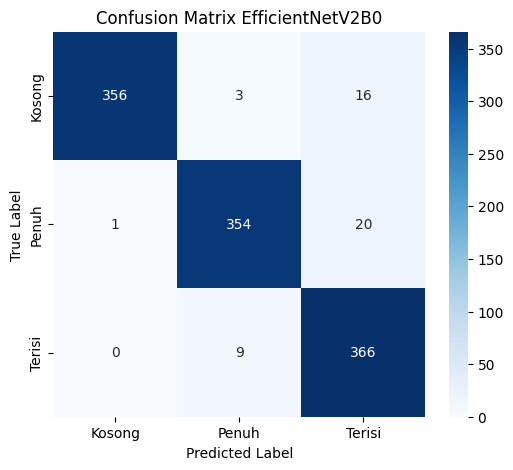

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix EfficientNetV2B0")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

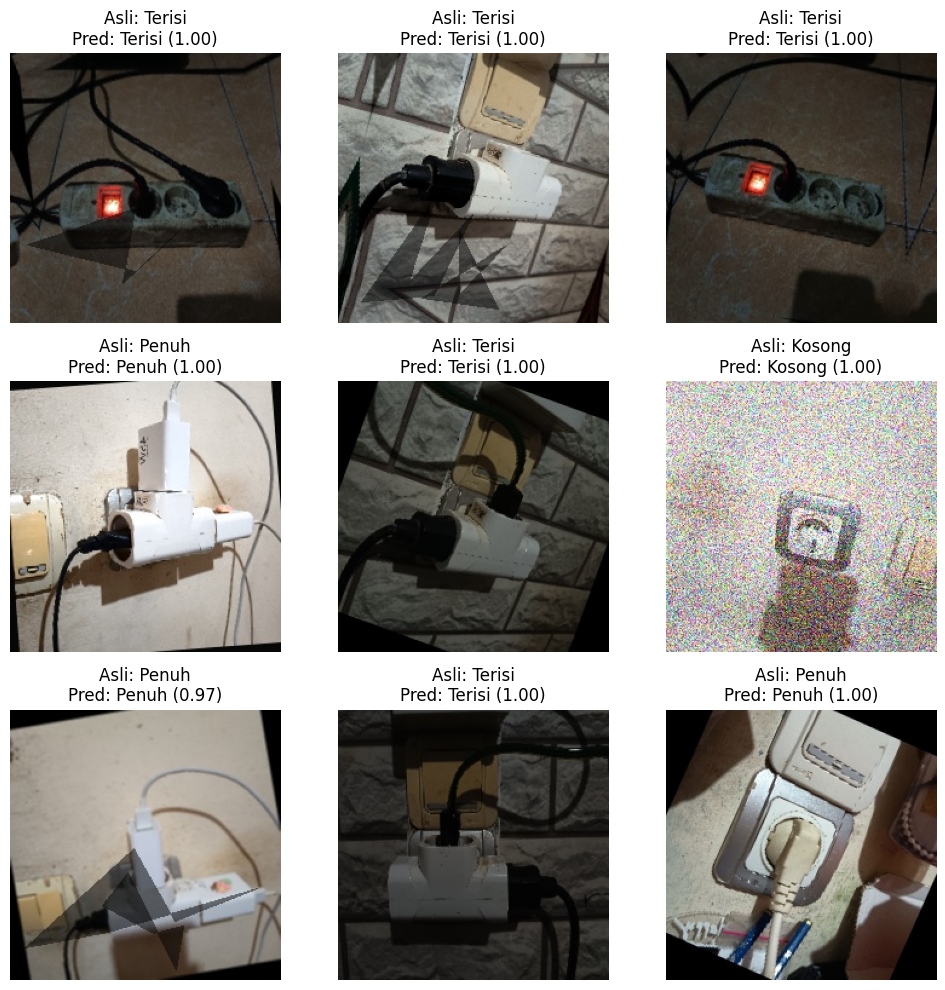

In [ ]:
def show_random_predictions_3x3(test_df, model, class_names, img_size=(224, 224)):
    sample_df = test_df.sample(n=9, random_state=random.randint(1, 9999)).reset_index(drop=True)

    plt.figure(figsize=(10, 10))

    for i, row in sample_df.iterrows():
        img_path = row["image_path"]
        true_label = row["label"]

        img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        img_input = np.expand_dims(img_array, axis=0)
        img_input = preprocess_input(img_input)

        pred_prob = model.predict(img_input, verbose=0)
        pred_idx = np.argmax(pred_prob)
        pred_label = class_names[pred_idx]
        confidence = np.max(pred_prob)

        plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.title(f"Asli: {true_label}\nPred: {pred_label} ({confidence:.2f})")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_random_predictions_3x3(test_df, model, class_names)

In [ ]:
save_path = "/content/drive/MyDrive/efficientnetv2b0_final_model.keras"

model.save(save_path)

print("Model berhasil disimpan di:")
print(save_path)

Model berhasil disimpan di:
/content/drive/MyDrive/efficientnetv2b0_final_model.keras


In [ ]:
best_model = tf.keras.models.load_model("best_efficientnetv2b0_model.keras")

print("Best model berhasil diload.")

Best model berhasil diload.


In [ ]:
for layer in best_model.layers:
    if len(layer.output.shape) == 4:
        print(layer.name, layer.output.shape)

input_layer_2 (None, 224, 224, 3)
rescaling_2 (None, 224, 224, 3)
normalization_2 (None, 224, 224, 3)
stem_conv (None, 112, 112, 32)
stem_bn (None, 112, 112, 32)
stem_activation (None, 112, 112, 32)
block1a_project_conv (None, 112, 112, 16)
block1a_project_bn (None, 112, 112, 16)
block1a_project_activation (None, 112, 112, 16)
block2a_expand_conv (None, 56, 56, 64)
block2a_expand_bn (None, 56, 56, 64)
block2a_expand_activation (None, 56, 56, 64)
block2a_project_conv (None, 56, 56, 32)
block2a_project_bn (None, 56, 56, 32)
block2b_expand_conv (None, 56, 56, 128)
block2b_expand_bn (None, 56, 56, 128)
block2b_expand_activation (None, 56, 56, 128)
block2b_project_conv (None, 56, 56, 32)
block2b_project_bn (None, 56, 56, 32)
block2b_drop (None, 56, 56, 32)
block2b_add (None, 56, 56, 32)
block3a_expand_conv (None, 28, 28, 128)
block3a_expand_bn (None, 28, 28, 128)
block3a_expand_activation (None, 28, 28, 128)
block3a_project_conv (None, 28, 28, 48)
block3a_project_bn (None, 28, 28, 48)
block

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [ ]:
def show_gradcam(img_path, model, class_names, last_conv_layer_name="top_conv", img_size=(224, 224)):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
    img_array = tf.keras.preprocessing.image.img_to_array(img)

    input_array = np.expand_dims(img_array, axis=0)
    input_array = preprocess_input(input_array)

    preds = model.predict(input_array, verbose=0)
    pred_idx = np.argmax(preds[0])
    pred_label = class_names[pred_idx]
    confidence = np.max(preds[0])

    heatmap = make_gradcam_heatmap(
        input_array,
        model,
        last_conv_layer_name,
        pred_index=pred_idx
    )

    original_img = cv2.imread(img_path)
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    original_img = cv2.resize(original_img, img_size)

    heatmap_resized = cv2.resize(heatmap, img_size)
    heatmap_resized = np.uint8(255 * heatmap_resized)

    heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    superimposed_img = cv2.addWeighted(original_img, 0.6, heatmap_color, 0.4, 0)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(original_img)
    plt.title("Gambar Asli")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_resized, cmap="jet")
    plt.title("Heatmap Grad-CAM")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(superimposed_img)
    plt.title(f"Pred: {pred_label}\nConf: {confidence:.2f}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

Label asli: Terisi
Path: /content/dataset/Terisi/Terisi_aug_2287.jpg


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_2']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


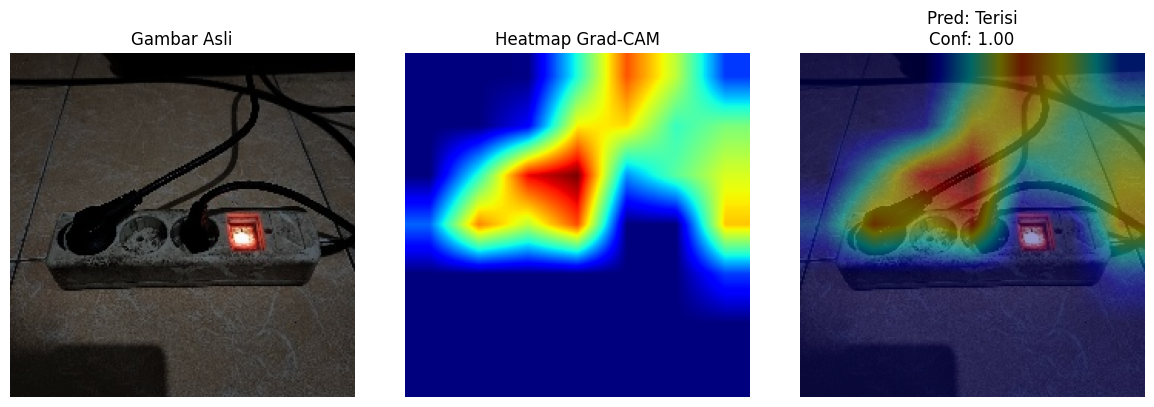

In [ ]:
sample = test_df.sample(1).iloc[0]

img_path = sample["image_path"]
true_label = sample["label"]

print("Label asli:", true_label)
print("Path:", img_path)

show_gradcam(
    img_path=img_path,
    model=best_model,
    class_names=class_names,
    last_conv_layer_name="top_conv"
)

In [ ]:
def show_feature_maps(img_path, model, layer_name="top_conv", img_size=(224, 224), max_features=16):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
    img_array = tf.keras.preprocessing.image.img_to_array(img)

    input_array = np.expand_dims(img_array, axis=0)
    input_array = preprocess_input(input_array)

    feature_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=model.get_layer(layer_name).output
    )

    feature_maps = feature_model.predict(input_array, verbose=0)

    feature_maps = feature_maps[0]

    total_features = min(max_features, feature_maps.shape[-1])

    plt.figure(figsize=(12, 12))

    for i in range(total_features):
        feature = feature_maps[:, :, i]

        plt.subplot(4, 4, i + 1)
        plt.imshow(feature, cmap="viridis")
        plt.title(f"Feature {i+1}")
        plt.axis("off")

    plt.suptitle(f"Feature Map Layer: {layer_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

Label asli: Kosong
Path: /content/dataset/Kosong/Kosong_aug_1732.jpg


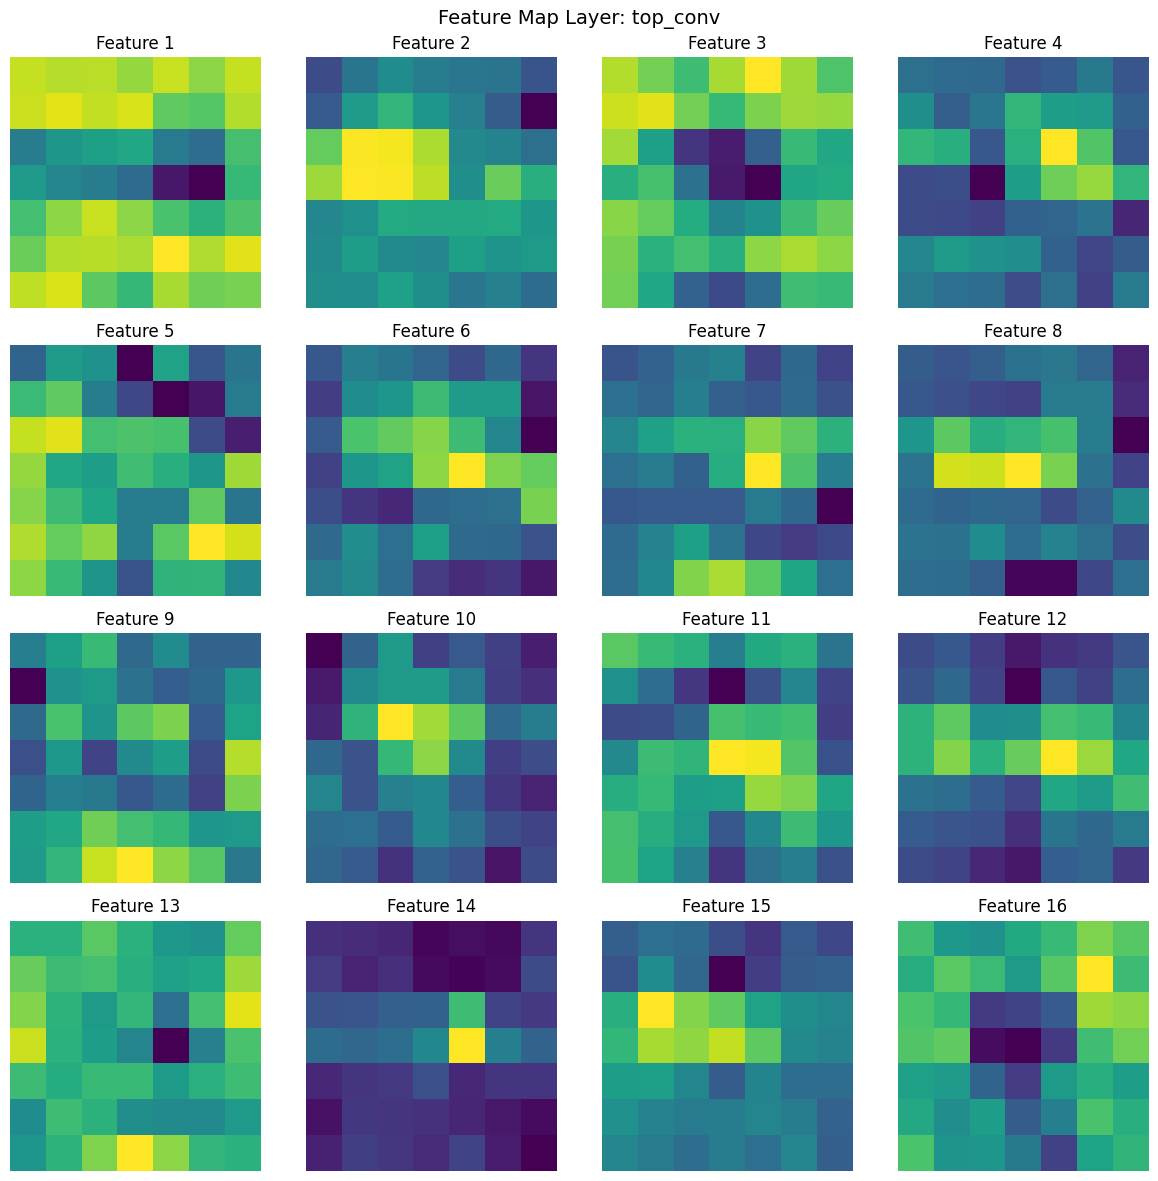

In [ ]:
sample = test_df.sample(1).iloc[0]

img_path = sample["image_path"]
true_label = sample["label"]

print("Label asli:", true_label)
print("Path:", img_path)

show_feature_maps(
    img_path=img_path,
    model=best_model,
    layer_name="top_conv",
    max_features=16
)

In [ ]:
def get_cnn_feature_importance(df_sample, model, layer_name="top_conv", img_size=(224, 224)):
    feature_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=model.get_layer(layer_name).output
    )

    all_importances = []

    for img_path in df_sample["image_path"]:
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
        img_array = tf.keras.preprocessing.image.img_to_array(img)

        input_array = np.expand_dims(img_array, axis=0)
        input_array = preprocess_input(input_array)

        feature_maps = feature_model.predict(input_array, verbose=0)

        importance = np.mean(feature_maps[0], axis=(0, 1))
        all_importances.append(importance)

    mean_importance = np.mean(all_importances, axis=0)

    feature_importance_df = pd.DataFrame({
        "Feature": [f"Feature {i}" for i in range(len(mean_importance))],
        "Importance": mean_importance
    }).sort_values(by="Importance", ascending=False)

    return feature_importance_df

In [ ]:
df_sample = test_df.sample(n=100, random_state=SEED)

feature_importance_df = get_cnn_feature_importance(
    df_sample=df_sample,
    model=best_model,
    layer_name="top_conv"
)

print("===== Top 20 Feature Importance EfficientNetV2B0 =====")
display(feature_importance_df.head(20))

===== Top 20 Feature Importance EfficientNetV2B0 =====


,Feature,Importance
582,Feature 582,5.920532
1262,Feature 1262,5.286112
1004,Feature 1004,5.146359
1202,Feature 1202,4.713367
256,Feature 256,3.886037
491,Feature 491,3.666918
561,Feature 561,3.318665
1166,Feature 1166,2.784281
956,Feature 956,2.479175
25,Feature 25,2.439523


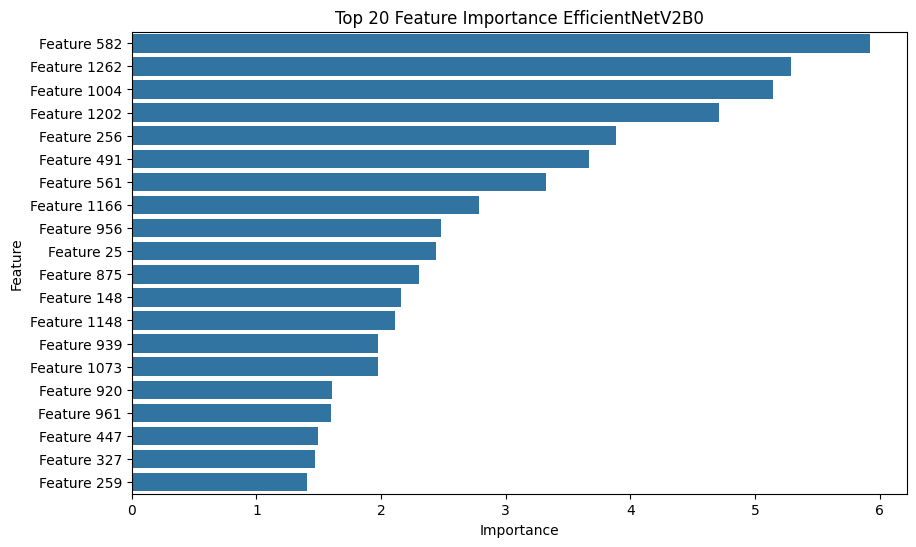

In [ ]:
top_n = 20
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Feature Importance EfficientNetV2B0")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()